# Installation and Downloading

In [4]:
import itertools
import math
import os
import random
from collections import Counter
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.modules.batchnorm import BatchNorm1d
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from sklearn.preprocessing import StandardScaler

In [5]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [6]:
seed_everything(42)

In [182]:
def show_learning_curves(history):
  plt.plot(history['loss_train'], label='Train Loss')
  plt.plot(history['loss_val'], label='Validation Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.title('Training and Validation Loss')
  plt.legend()
  num_epochs = len(history['loss_train'])
  plt.xticks(np.arange(0, num_epochs, 5))
  plt.grid(True)
  plt.show()

In [8]:
def get_prediction(model, test_dataset, featured=False):
  model.eval()
  predictions = []
  test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)
  if featured:
    with torch.no_grad():
        for batch in test_loader:
            X_dna_batch = batch[0].to(device)
            f_batch = batch[2].to(device).float()
            logits = model(X_dna_batch, f_batch)
            probs = torch.sigmoid(logits)
            predictions.append(probs.cpu().numpy())
    y_prob = np.concatenate(predictions, axis=0).flatten()
    y_pred_labels = (y_prob > 0.5).astype(int)

  else:
    with torch.no_grad():
      for batch in test_loader:
        X_batch = batch[0].to(device)
        logits = model(X_batch)
        probs = torch.sigmoid(logits)
        predictions.append(probs.cpu().numpy())
    y_prob = np.concatenate(predictions, axis=0).flatten()
    y_pred_labels = (y_prob >= 0.5).astype(int)

  return y_prob, y_pred_labels

In [9]:
def show_roc_curves(fpr_arr, tpr_arr, context_size, model_name):
    plt.figure(figsize=(8, 6))
    models = [
        (fpr_arr[0], tpr_arr[0], 'baseline model', 'black', '-', 1.0),
        (fpr_arr[1], tpr_arr[1], 'weighted model', 'orange', '-', 0.8),
        (fpr_arr[2], tpr_arr[2], 'featured model', 'red', '-', 1.0),
    ]

    for fpr, tpr, label, color, linestyle, alpha_val in models:
        current_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, color=color, linestyle=linestyle, alpha=alpha_val,
                 label=f'{label} (ROC-AUC = {current_auc:.2f})')

    plt.plot(np.linspace(0, 1, 10), np.linspace(0, 1, 10), '--', color='blue', lw=2)
    plt.ylabel('True Positive Rate', fontsize=14)
    plt.xlabel('False Positive Rate', fontsize=14)
    plt.title(f'ROC-curves of {model_name} Model\n for {context_size} bp window', fontsize=16)
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(alpha=0.3)
    plt.show()

In [10]:
def show_pr_curves(precision_arr, recall_arr, random_level, context_size, model_name):
  plt.figure(figsize=(8, 6))
  pr_models = [
      (precision_arr[0], recall_arr[0], 'baseline model', 'black', 1.0),
      (precision_arr[1], recall_arr[1], 'weighted model', 'orange', 0.8),
      (precision_arr[2], recall_arr[2], 'featured model', 'red', 1.0),
  ]

  for prec, rec, label, color, alpha_val in pr_models:
      ap_score = auc(rec, prec)
      plt.plot(rec, prec, lw=2, color=color, alpha=alpha_val,
              label=f'{label} (PR-AUC = {ap_score:.2f})')
  plt.axhline(y=random_level, color='blue', linestyle='--', lw=2)
  plt.xlabel('Recall', fontsize=14)
  plt.ylabel('Precision', fontsize=14)
  plt.xticks(fontsize=12)
  plt.yticks(fontsize=12)
  plt.title(f'PR-curves of {model_name} model\n for {context_size} bp window', fontsize=16)
  plt.legend(loc="upper right", fontsize=12)
  plt.grid(alpha=0.3)
  plt.show()

In [11]:
data = np.load('data/processed/models_input.npz')

X_50 = data['X_50']
X_30 = data['X_30']
y = data['y']
Z = data['Z']
pos = data['pos']

weights = 1 + np.log1p(Z)

In [12]:
X_50 = X_50.reshape((X_50.shape[0], int(X_50.shape[1]/4), 4))
X_30 = X_30.reshape((X_30.shape[0], int(X_30.shape[1]/4), 4))

# Data Preparation

In [13]:
X_train_full_50, X_test_50, y_train_full_50, y_test_50, w_train_full_50, w_test_50 = train_test_split(
    X_50, y, weights,
    test_size=0.2, random_state=42, stratify=y
)

X_train_50, X_val_50, y_train_50, y_val_50, w_train_50, w_val_50 = train_test_split(
    X_train_full_50, y_train_full_50, w_train_full_50,
    test_size=0.3, random_state=42, stratify=y_train_full_50
)


def prepare_tensors(X_data, y_data, w_data=None):
    X_tensor = torch.tensor(X_data, dtype=torch.float32)
    y_tensor = torch.tensor(y_data, dtype=torch.float32).reshape(-1, 1)

    if w_data is not None:
        w_tensor = torch.tensor(w_data, dtype=torch.float32).reshape(-1, 1)
        return TensorDataset(X_tensor, y_tensor, w_tensor)

    return TensorDataset(X_tensor, y_tensor)


train_dataset_50 = prepare_tensors(X_train_50, y_train_50, w_train_50)
val_dataset_50 = prepare_tensors(X_val_50, y_val_50, w_val_50)
test_dataset_50 = prepare_tensors(X_test_50, y_test_50)


train_loader_50 = DataLoader(train_dataset_50, batch_size=128, shuffle=True)
val_loader_50 = DataLoader(val_dataset_50, batch_size=128, shuffle=False)

In [14]:
X_train_full_30, X_test_30, y_train_full_30, y_test_30, w_train_full_30, w_test_30 = train_test_split(
    X_30, y, weights,
    test_size=0.2, random_state=42, stratify=y
)

X_train_30, X_val_30, y_train_30, y_val_30, w_train_30, w_val_30 = train_test_split(
    X_train_full_30, y_train_full_30, w_train_full_30,
    test_size=0.3, random_state=42, stratify=y_train_full_30
)



train_dataset_30 = prepare_tensors(X_train_30, y_train_30, w_train_30)
val_dataset_30 = prepare_tensors(X_val_30, y_val_30, w_val_30)
test_dataset_30 = prepare_tensors(X_test_30, y_test_30)


train_loader_30 = DataLoader(train_dataset_30, batch_size=128, shuffle=True)
val_loader_30 = DataLoader(val_dataset_30, batch_size=128, shuffle=False)

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n0 = np.sum(y_train_50 == 0)
n1 = np.sum(y_train_50 == 1)
pos_weight_val = torch.tensor([n0 / n1], dtype=torch.float32).to(device)

lr = 1e-3
n_epochs = 35
weight_decay = 1e-3

# Evaluation and Training

In [16]:
def evaluate(model, loader, loss_fn, use_sample_weights=False):
    model.eval()
    loss_total = 0
    y_true_list = []
    y_pred_probs_list = []

    with torch.no_grad():
        for batch in loader:
            X_batch = batch[0].to(device)
            y_batch = batch[1].to(device).float()

            logits = model(X_batch)
            raw_loss = loss_fn(logits, y_batch)

            if use_sample_weights and len(batch) > 2:
                w_batch = batch[2].to(device).float()
                loss_tensor = (raw_loss * w_batch).mean()
            else:
                loss_tensor = raw_loss.mean()

            loss_total += loss_tensor.item()

            y_probs = torch.sigmoid(logits)
            y_true_list.extend(y_batch.cpu().numpy())
            y_pred_probs_list.extend(y_probs.cpu().numpy())

    loss_avg = loss_total / len(loader)
    y_true_arr = np.array(y_true_list)
    y_probs_arr = np.array(y_pred_probs_list)
    y_pred_labels_arr = (y_probs_arr >= 0.5).astype(int)

    try:
        rocauc = roc_auc_score(y_true_arr, y_probs_arr)
    except:
        rocauc = 0.5

    f1 = f1_score(y_true_arr, y_pred_labels_arr)

    return loss_avg, rocauc, f1

In [17]:
def train(model, loss_fn, optimizer, train_loader, val_loader, n_epoch=6,
          show_step=1, scheduler=None, use_sample_weights=True, save_best=True):
    data = {
        'loss_train': [],
        'loss_val': [],
        'rocauc': [],
        'f1_score': []
    }

    best_val_loss = float('inf')
    best_model_state = None

    for epoch in range(n_epoch):
        should_show = (epoch % show_step == 0)


        model.train()

        train_iterator = tqdm(
            train_loader,
            desc=f"Epoch {epoch}",
            disable=not should_show,
            leave=True)

        for batch in train_iterator:
            X_batch, y_batch, w_batch = batch
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).float()
            w_batch = w_batch.to(device).float()

            y_pred = model(X_batch)
            raw_loss = loss_fn(y_pred, y_batch)

            if use_sample_weights:
                loss = (raw_loss * w_batch).mean()
            else:
                loss = raw_loss.mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()


        loss_train_epoch, _, _ = evaluate(model, train_loader, loss_fn, use_sample_weights)
        loss_val_epoch, rocauc_epoch, f1_epoch = evaluate(model, val_loader, loss_fn, use_sample_weights)

        if save_best:
            if loss_val_epoch < best_val_loss:
                best_val_loss = loss_val_epoch
                best_model_state = deepcopy(model.state_dict())
                if should_show:
                    print(f'New best model found at epoch {epoch} (Val Loss: {best_val_loss:.4f})')

        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(loss_val_epoch)
            else:
                scheduler.step()

        if should_show:
            print(f'n_epoch = {epoch}')
            print(f'Train loss: {loss_train_epoch:.4f}')
            print(f'Val loss: {loss_val_epoch:.4f}')
            print(f'Val Roc-auc: {rocauc_epoch:.4f}')
            print(f'Val F1-score: {f1_epoch:.4f}\n')

        data['loss_train'].append(loss_train_epoch)
        data['loss_val'].append(loss_val_epoch)
        data['rocauc'].append(rocauc_epoch)
        data['f1_score'].append(f1_epoch)

    if save_best and best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Final model loaded with best Val Loss: {best_val_loss:.4f}")

    return model, data

# CNN Classification

## Model Structure

In [18]:
def get_reverse_complement(x):
    x_rc = torch.flip(x, dims=[2])
    x_rc = x_rc[:, [3, 2, 1, 0], :]
    return x_rc

In [19]:
class CNN_model(nn.Module):
    def __init__(self, input_len=102, k1=5, k2=3,
                 out1=16, out2=32,
                 drop_conv=0.2, drop_fc=0.4):

        super(CNN_model, self).__init__()

        self.conv1 = nn.Conv1d(4, out1, kernel_size=k1, padding='same')
        self.bn1 = nn.BatchNorm1d(out1)
        self.pool1 = nn.AvgPool1d(kernel_size=2)
        self.conv2 = nn.Conv1d(out1, out2, kernel_size=k2, padding='same')
        self.bn2 = nn.BatchNorm1d(out2)
        self.dropout_conv = nn.Dropout1d(drop_conv)
        self.dropout_fc = nn.Dropout(drop_fc)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(int(out2 * input_len/2), 64) ##
        self.fc2 = nn.Linear(64, 1)

    def _forward_single_strand(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = self.dropout_conv(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.dropout_conv(x)
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout_fc(x)
        x = self.fc2(x)

        return x

    def forward(self, x, use_rc=True):
        x_forward = x.view(-1, 4, x.shape[1])
        out_forward = self._forward_single_strand(x_forward)
        if use_rc:
            x_rc = get_reverse_complement(x_forward)
            out_rc = self._forward_single_strand(x_rc)
            return (out_forward + out_rc) / 2.0
        else:
            return out_forward

## 50-bp Nucleotide Context

In [ ]:
# Parameters tuned using cross-validation
model_cnn_50 = CNN_model(k1=5,
                         k2=3,
                         out1=16,
                         out2=32,
                         drop_conv=0.2,
                         drop_fc=0.6).to(device)


loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val)
optimizer = torch.optim.Adam(model_cnn_50.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2)

model_cnn_trained_50, history_cnn_50 = train(
    model=model_cnn_50,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_loader=train_loader_50,
    val_loader=val_loader_50,
    n_epoch=n_epochs,
    show_step=10,
    scheduler=scheduler,
    use_sample_weights=False,
    save_best=True)

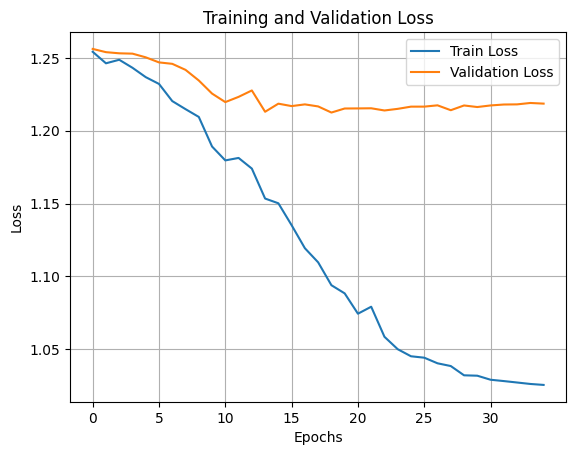

In [183]:
show_learning_curves(history_cnn_50)

In [22]:
y_prob_cnn_50, y_pred_labels_cnn_50 = get_prediction(model_cnn_trained_50, test_dataset_50)

print(classification_report(y_test_50, y_pred_labels_cnn_50))
print(f"ROC-AUC: {roc_auc_score(y_test_50, y_prob_cnn_50.flatten()):.4f}")

              precision    recall  f1-score   support

           0       0.93      0.66      0.77      4230
           1       0.14      0.54      0.22       433

    accuracy                           0.65      4663
   macro avg       0.54      0.60      0.50      4663
weighted avg       0.86      0.65      0.72      4663

ROC-AUC: 0.6307


In [23]:
fpr_50_1, tpr_50_1, _ = roc_curve(y_test_50,  y_prob_cnn_50)

In [24]:
precision_50_1, recall_50_1, thresholds_50_1 = precision_recall_curve(y_test_50, y_prob_cnn_50)

## 50-bp Nucleotide Context (Weighted)

In [ ]:
model_cnn_50_w = CNN_model(k1=5,
                          k2=3,
                          out1=16,
                          out2=32,
                          drop_conv=0.2,
                          drop_fc=0.6).to(device)


loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val, reduction='none')
optimizer = torch.optim.Adam(model_cnn_50_w.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2)


model_cnn_trained_50_w, history_cnn_50_w = train(
    model=model_cnn_50_w,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_loader=train_loader_50,
    val_loader=val_loader_50,
    n_epoch=n_epochs,
    show_step=10,
    scheduler=scheduler,
    use_sample_weights=True,
    save_best=True)

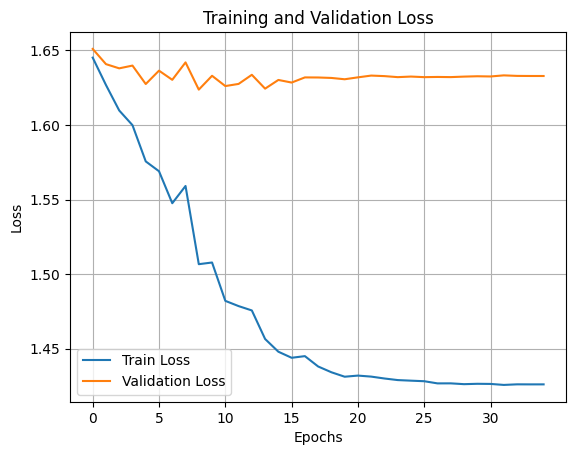

In [184]:
show_learning_curves(history_cnn_50_w)

In [27]:
y_prob_cnn_50_w, y_pred_labels_cnn_50_w = get_prediction(model_cnn_trained_50_w, test_dataset_50)

print(classification_report(y_test_50, y_pred_labels_cnn_50_w))
print(f"ROC-AUC: {roc_auc_score(y_test_50, y_prob_cnn_50_w.flatten()):.4f}")

              precision    recall  f1-score   support

           0       0.94      0.30      0.45      4230
           1       0.11      0.82      0.19       433

    accuracy                           0.35      4663
   macro avg       0.52      0.56      0.32      4663
weighted avg       0.86      0.35      0.43      4663

ROC-AUC: 0.6107


In [28]:
fpr_50_w_1, tpr_50_w_1, _ = roc_curve(y_test_50,  y_prob_cnn_50_w)

In [29]:
precision_50_w_1, recall_50_w_1, thresholds_50_w_1 = precision_recall_curve(y_test_50, y_prob_cnn_50_w)

## 30-bp Nucleotide Context

In [ ]:
model_cnn_30 = CNN_model(input_len=62,
                         k1=5,
                         k2=3,
                         out1=16,
                         out2=32,
                         drop_conv=0.4,
                         drop_fc=0.5).to(device)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val)
optimizer = torch.optim.Adam(model_cnn_30.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2)


model_cnn_trained_30, history_cnn_30 = train(
    model=model_cnn_30,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_loader=train_loader_30,
    val_loader=val_loader_30,
    n_epoch=n_epochs,
    show_step=10,
    scheduler=scheduler,
    use_sample_weights=False,
    save_best=True)

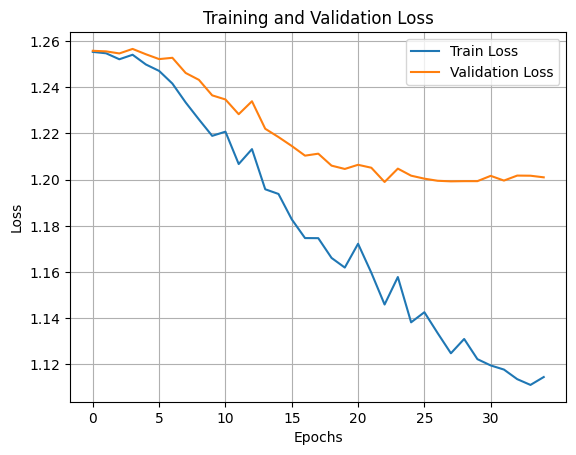

In [185]:
show_learning_curves(history_cnn_30)

In [32]:
y_prob_cnn_30, y_pred_labels_cnn_30 = get_prediction(model_cnn_trained_30, test_dataset_30)

print(classification_report(y_test_30, y_pred_labels_cnn_30))
print(f"ROC-AUC: {roc_auc_score(y_test_30, y_prob_cnn_30.flatten()):.4f}")

              precision    recall  f1-score   support

           0       0.93      0.56      0.70      4230
           1       0.13      0.62      0.21       433

    accuracy                           0.57      4663
   macro avg       0.53      0.59      0.45      4663
weighted avg       0.86      0.57      0.66      4663

ROC-AUC: 0.6351


In [33]:
fpr_30_1, tpr_30_1, _ = roc_curve(y_test_30,  y_prob_cnn_30)

In [34]:
precision_30_1, recall_30_1, thresholds_30_1 = precision_recall_curve(y_test_30, y_prob_cnn_30)

## 30-bp Nucleotide Context (Weighted)

In [ ]:
model_cnn_30_w = CNN_model(input_len=62,
                            k1=5,
                            k2=3,
                            out1=16,
                            out2=32,
                            drop_conv=0.4,
                            drop_fc=0.5).to(device)


loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val, reduction='none')
optimizer = torch.optim.Adam(model_cnn_30_w.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2)


model_cnn_trained_30_w, history_cnn_30_w = train(
    model=model_cnn_30_w,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_loader=train_loader_30,
    val_loader=val_loader_30,
    n_epoch=n_epochs,
    show_step=10,
    scheduler=scheduler,
    use_sample_weights=True,
    save_best=True)

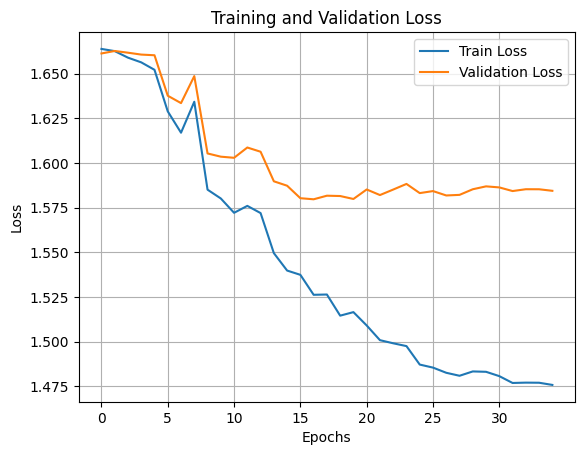

In [186]:
show_learning_curves(history_cnn_30_w)

In [37]:
y_prob_cnn_30_w, y_pred_labels_cnn_30_w = get_prediction(model_cnn_trained_30_w, test_dataset_30)

print(classification_report(y_test_30, y_pred_labels_cnn_30_w))
print(f"ROC-AUC: {roc_auc_score(y_test_30, y_prob_cnn_30_w.flatten()):.4f}")

              precision    recall  f1-score   support

           0       0.95      0.16      0.27      4230
           1       0.10      0.92      0.18       433

    accuracy                           0.23      4663
   macro avg       0.53      0.54      0.23      4663
weighted avg       0.87      0.23      0.26      4663

ROC-AUC: 0.6347


In [38]:
fpr_30_w_1, tpr_30_w_1, _ = roc_curve(y_test_30,  y_prob_cnn_30_w)

In [39]:
precision_30_w_1, recall_30_w_1, thresholds_30_w_1 = precision_recall_curve(y_test_30, y_prob_cnn_30_w)

# Attention-based CNN Classification

## Model Structure

In [40]:
class AttentionBlock(nn.Module):
    def __init__(self, in_channels):
        super(AttentionBlock, self).__init__()

        self.query = nn.Linear(in_channels, in_channels)
        self.key = nn.Linear(in_channels, in_channels)
        self.value = nn.Linear(in_channels, in_channels)

    def forward(self, x):
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        scores = Q @ K.transpose(-2, -1) / math.sqrt(Q.size(-1))
        weights = F.softmax(scores, dim=-1)
        output = weights @ V
        return output


class CNN_attention(nn.Module):
    def __init__(self, input_len=102, k1=5, k2=3,
                 out1=32, out2=64,
                 drop_conv=0.1, drop_fc=0.4):
        super().__init__()

        self.conv1 = nn.Conv1d(4, out1, kernel_size=k1, padding='same')
        self.bn1 = nn.BatchNorm1d(out1)
        self.conv2 = nn.Conv1d(out1, out2, kernel_size=k2, padding='same')
        self.bn2 = nn.BatchNorm1d(out2)
        self.pool1 = nn.AvgPool1d(kernel_size=2)
        self.attention = AttentionBlock(out2)
        self.dropout_conv = nn.Dropout1d(drop_conv)
        self.dropout_fc = nn.Dropout(drop_fc)
        self.flatten = nn.Flatten()
        self.fc1_input_dim = int(out2 * input_len / 2)
        self.fc1 = nn.Linear(self.fc1_input_dim, 64)
        self.fc2 = nn.Linear(64, 1)

    def _forward_single_strand(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = self.dropout_conv(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.dropout_conv(x)
        x = x.permute(0, 2, 1)
        identity = x
        x = self.attention(x)
        x = x + identity
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout_fc(x)
        x = self.fc2(x)
        return x

    def forward(self, x, use_rc=True):
        x_forward = x.view(x.size(0), 4, -1)
        out_forward = self._forward_single_strand(x_forward)
        if use_rc:
            x_rc = get_reverse_complement(x_forward)
            out_rc = self._forward_single_strand(x_rc)
            return (out_forward + out_rc) / 2.0
        else:
            return out_forward

## 50-bp Nucleotide Context

In [ ]:
model_cnn_attention_50 = CNN_attention(input_len=102,
                                        k1=7,
                                        k2=5,
                                        out1=16,
                                        out2=64,
                                        drop_conv=0.4,
                                        drop_fc=0.5).to(device)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val)
optimizer = torch.optim.Adam(model_cnn_attention_50.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2)

model_cnna_trained_50, history_cnna_50 = train(
    model=model_cnn_attention_50,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_loader=train_loader_50,
    val_loader=val_loader_50,
    n_epoch=n_epochs,
    show_step=10,
    scheduler=scheduler,
    use_sample_weights=False,
    save_best=True)

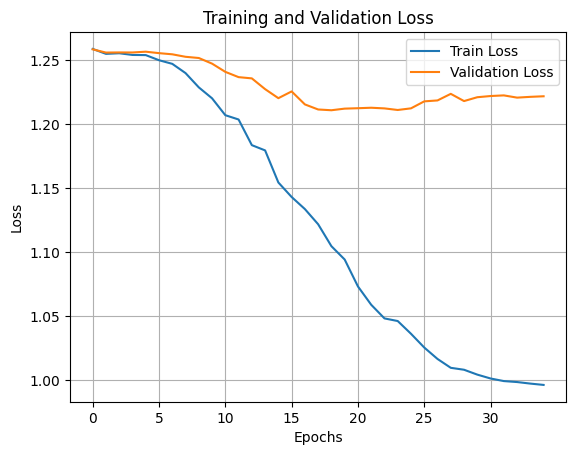

In [187]:
show_learning_curves(history_cnna_50)

In [43]:
y_prob_cnna_50, y_pred_labels_cnna_50 = get_prediction(model_cnna_trained_50, test_dataset_50)

print(classification_report(y_test_50, y_pred_labels_cnna_50))
print(f"ROC-AUC: {roc_auc_score(y_test_50, y_prob_cnna_50.flatten()):.4f}")

              precision    recall  f1-score   support

           0       0.93      0.62      0.74      4230
           1       0.13      0.55      0.21       433

    accuracy                           0.61      4663
   macro avg       0.53      0.58      0.48      4663
weighted avg       0.86      0.61      0.69      4663

ROC-AUC: 0.6256


In [117]:
fpr_50_2, tpr_50_2, _ = roc_curve(y_test_50,  y_prob_cnna_50)

In [118]:
precision_50_2, recall_50_2, thresholds_50_2 = precision_recall_curve(y_test_50, y_prob_cnna_50)

## 50-bp Nucleotide Context (Weighted)

In [ ]:
model_cnn_attention_50_w = CNN_attention(input_len=102,
                                        k1=7,
                                        k2=5,
                                        out1=16,
                                        out2=64,
                                        drop_conv=0.4,
                                        drop_fc=0.5).to(device)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val, reduction='none')
optimizer = torch.optim.Adam(model_cnn_attention_50_w.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2)

model_cnna_trained_50_w, history_cnna_50_w = train(
    model=model_cnn_attention_50_w,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_loader=train_loader_50,
    val_loader=val_loader_50,
    n_epoch=n_epochs,
    show_step=10,
    scheduler=scheduler,
    use_sample_weights=True,
    save_best=True)

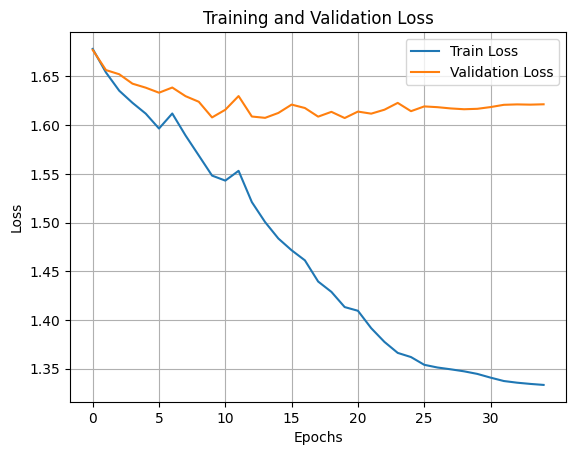

In [188]:
show_learning_curves(history_cnna_50_w)

In [114]:
y_prob_cnna_50_w, y_pred_labels_cnna_50_w = get_prediction(model_cnna_trained_50_w, test_dataset_50)

print(classification_report(y_test_50, y_pred_labels_cnna_50_w))
print(f"ROC-AUC: {roc_auc_score(y_test_50, y_prob_cnna_50_w.flatten()):.4f}")

              precision    recall  f1-score   support

           0       0.95      0.25      0.40      4230
           1       0.11      0.86      0.19       433

    accuracy                           0.31      4663
   macro avg       0.53      0.56      0.29      4663
weighted avg       0.87      0.31      0.38      4663

ROC-AUC: 0.6330


In [115]:
fpr_50_w_2, tpr_50_w_2, _ = roc_curve(y_test_50,  y_prob_cnna_50_w)

In [116]:
precision_50_w_2, recall_50_w_2, thresholds_50_w_2 = precision_recall_curve(y_test_50, y_prob_cnna_50_w)

## 30-bp Nucleotide Context


In [ ]:
model_cnna_30 = CNN_attention(input_len=62,
                                        k1=5,
                                        k2=3,
                                        out1=16,
                                        out2=64,
                                        drop_conv=0.4,
                                        drop_fc=0.6).to(device)


loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val)
optimizer = torch.optim.Adam(model_cnna_30.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2)

model_cnna_trained_30, history_cnna_30 = train(
    model=model_cnna_30,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_loader=train_loader_30,
    val_loader=val_loader_30,
    n_epoch=n_epochs,
    show_step=10,
    scheduler=scheduler,
    use_sample_weights=False,
    save_best=True)

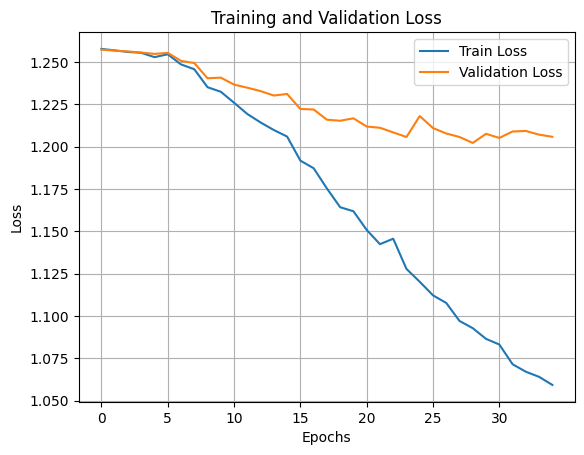

In [189]:
show_learning_curves(history_cnna_30)

In [53]:
y_prob_cnna_30, y_pred_labels_cnna_30 = get_prediction(model_cnna_trained_30, test_dataset_30)

print(classification_report(y_test_30, y_pred_labels_cnna_30))
print(f"ROC-AUC: {roc_auc_score(y_test_30, y_prob_cnna_30.flatten()):.4f}")

              precision    recall  f1-score   support

           0       0.94      0.56      0.70      4230
           1       0.13      0.63      0.21       433

    accuracy                           0.57      4663
   macro avg       0.53      0.60      0.46      4663
weighted avg       0.86      0.57      0.66      4663

ROC-AUC: 0.6349


In [111]:
fpr_30_2, tpr_30_2, _ = roc_curve(y_test_30,  y_prob_cnna_30)

In [112]:
precision_30_2, recall_30_2, thresholds_30_2 = precision_recall_curve(y_test_30, y_prob_cnna_30)

## 30-bp Nucleotide Context (Weighted)


In [ ]:
model_cnn_attention_30_w = CNN_attention(input_len=62,
                                        k1=5,
                                        k2=3,
                                        out1=16,
                                        out2=64,
                                        drop_conv=0.4,
                                        drop_fc=0.6).to(device)


loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val, reduction='none')
optimizer = torch.optim.Adam(model_cnn_attention_30_w.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2)

model_cnna_trained_30_w, history_cnna_30_w = train(
    model=model_cnn_attention_30_w,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_loader=train_loader_30,
    val_loader=val_loader_30,
    n_epoch=n_epochs,
    show_step=10,
    scheduler=scheduler,
    use_sample_weights=True,
    save_best=True)

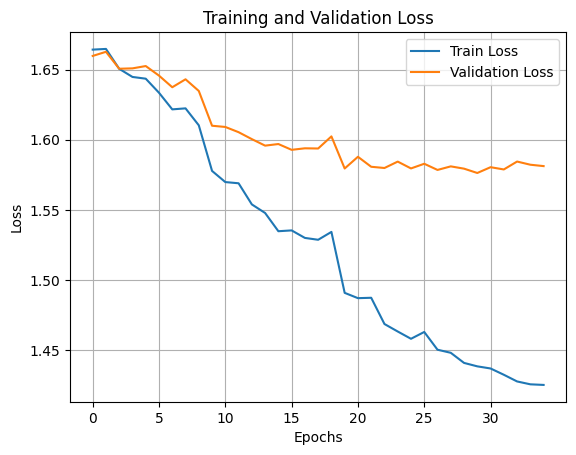

In [190]:
show_learning_curves(history_cnna_30_w)

In [108]:
y_prob_cnna_30_w, y_pred_labels_cnna_30_w = get_prediction(model_cnna_trained_30_w, test_dataset_30)

print(classification_report(y_test_30, y_pred_labels_cnna_30_w))
print(f"ROC-AUC: {roc_auc_score(y_test_30, y_prob_cnna_30_w.flatten()):.4f}")

              precision    recall  f1-score   support

           0       0.94      0.30      0.46      4230
           1       0.11      0.82      0.19       433

    accuracy                           0.35      4663
   macro avg       0.53      0.56      0.33      4663
weighted avg       0.87      0.35      0.44      4663

ROC-AUC: 0.6346


In [109]:
fpr_30_w_2, tpr_30_w_2, _ = roc_curve(y_test_30,  y_prob_cnna_30_w)

In [110]:
precision_30_w_2, recall_30_w_2, thresholds_30_w_2 = precision_recall_curve(y_test_30, y_prob_cnna_30_w)

# Adding Features

In [61]:
df = pd.DataFrame({'pos': pos, 'seq_50':list(X_50), 'seq_30':list(X_30), 'label': y})
score_df = pd.read_pickle('data/processed/grantham_score.pkl.gz')
score_df.score = score_df.score.fillna(215)

df = df.merge(score_df[['pos', 'score']], on='pos', how='left')
df.score = df.score.fillna(0)

In [62]:
add_features = pd.read_pickle('data/processed/dataframe_features.pkl.gz')

In [63]:
df_featured = df[df.pos.isin(add_features.pos_in_align)]
df_featured = df_featured.merge(
    add_features[['pos_in_align', 'Free_Energy_kcal_mol', 'Stem_Length', 'Loop_Length', 'energy_isna', 'stem_isna', 'loop_isna']],
    left_on='pos',
    right_on='pos_in_align',
    how='left'
)

df_featured = df_featured.drop(columns=['pos_in_align'])

In [64]:
features = df_featured[['score', 'Free_Energy_kcal_mol', 'Stem_Length', 'Loop_Length', 'energy_isna', 'stem_isna', 'loop_isna']].values
y_featured = df_featured.label.to_numpy()

# CNN Classification with Additional Features

## Integration of Features

In [143]:
def prepare_tensors_featured(X_data, y_data, f_data, w_data=None):
    X_tensor = torch.tensor(X_data, dtype=torch.float32)
    y_tensor = torch.tensor(y_data, dtype=torch.float32).reshape(-1, 1)
    f_tensor = torch.tensor(f_data, dtype=torch.float32)

    if w_data is not None:
        w_tensor = torch.tensor(w_data, dtype=torch.float32).reshape(-1, 1)
        return TensorDataset(X_tensor, y_tensor, f_tensor, w_tensor)

    return TensorDataset(X_tensor, y_tensor, f_tensor)


X_train_full_50_, X_test_50_, y_train_full_50_, y_test_50_, f_train_full_50_, f_test_50_ = train_test_split(
    np.stack(df_featured.seq_50.values), y_featured, features,
    test_size=0.2, random_state=42, stratify=y_featured)

X_train_50_, X_val_50_, y_train_50_, y_val_50_, f_train_50_, f_val_50_ = train_test_split(
    X_train_full_50_, y_train_full_50_, f_train_full_50_,
    test_size=0.3, random_state=42, stratify=y_train_full_50_)

scaler = StandardScaler()

f_train_scaled_50_ = scaler.fit_transform(f_train_50_)
f_val_scaled_50_ = scaler.transform(f_val_50_)
f_test_scaled_50_ = scaler.transform(f_test_50_)


train_dataset_featured_50_ = prepare_tensors_featured(X_train_50_, y_train_50_, f_train_scaled_50_)
val_dataset_featured_50_ = prepare_tensors_featured(X_val_50_, y_val_50_, f_val_scaled_50_)
test_dataset_featured_50_ = prepare_tensors_featured(X_test_50_, y_test_50_, f_test_scaled_50_)


train_loader_featured_50_ = DataLoader(train_dataset_featured_50_, batch_size=128, shuffle=True)
val_loader_featured_50_ = DataLoader(val_dataset_featured_50_, batch_size=128, shuffle=False)

In [144]:
def evaluate_featured(model, loader, loss_fn):
    model.eval()
    loss_total = 0
    y_true_list = []
    y_pred_list = []

    with torch.no_grad():
        for batch in loader:

            X_batch, y_batch, f_batch = batch[:3]

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).float()
            f_batch = f_batch.to(device).float()

            logits = model(X_batch, f_batch)

            loss_tensor = loss_fn(logits, y_batch)
            loss_total += loss_tensor.mean().item()

            y_probs = torch.sigmoid(logits)
            y_true_list.extend(y_batch.cpu().numpy())
            y_pred_list.extend(y_probs.cpu().numpy())

    loss_avg = loss_total / len(loader)
    y_true_arr = np.array(y_true_list)
    y_pred_arr = np.array(y_pred_list)
    try:
        rocauc = roc_auc_score(y_true_arr, y_pred_arr)
    except:
        rocauc = 0.5

    y_pred_labels = (y_pred_arr > 0.5).astype(int)
    f1 = f1_score(y_true_arr, y_pred_labels)

    return loss_avg, rocauc, f1

In [145]:
def train_featured(model, loss_fn, optimizer, train_loader, val_loader, n_epoch=6,
          show_step=1, scheduler=None, use_sample_weights=False, save_best=True):
    data = {
        'loss_train': [],
        'loss_val': [],
        'rocauc': [],
        'f1_score': []
    }

    best_val_loss = float('inf')
    best_model_state = None

    for epoch in range(n_epoch):
        should_show = (epoch % show_step == 0)
        model.train()

        train_iterator = tqdm(
            train_loader,
            desc=f"Epoch {epoch}",
            disable=not should_show,
            leave=True)

        for batch in train_iterator:
            if use_sample_weights:
              X_batch, y_batch, f_batch, w_batch = batch
              w_batch = w_batch.to(device).float()
            else:
              X_batch, y_batch, f_batch = batch

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).float()

            f_batch = f_batch.to(device).float()

            y_pred = model(X_batch, f_batch)

            raw_loss = loss_fn(y_pred, y_batch)
            if use_sample_weights:
                loss = (raw_loss * w_batch).mean()
            else:
                loss = raw_loss.mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()


        loss_train_epoch, _, _ = evaluate_featured(model, train_loader, loss_fn)
        loss_val_epoch, rocauc_epoch, f1_epoch = evaluate_featured(model, val_loader, loss_fn)

        if save_best:
            if loss_val_epoch < best_val_loss:
                best_val_loss = loss_val_epoch

                best_model_state = deepcopy(model.state_dict())
                if should_show:
                    print(f'New best model found at epoch {epoch} (Val Loss: {best_val_loss:.4f})')


        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(loss_val_epoch)
            else:
                scheduler.step()

        if should_show:
            print(f'n_epoch = {epoch}')
            print(f'Train loss: {loss_train_epoch:.4f}')
            print(f'Val loss: {loss_val_epoch:.4f}')
            print(f'Val Roc-auc: {rocauc_epoch:.4f}')
            print(f'Val F1-score: {f1_epoch:.4f}\n')

        data['loss_train'].append(loss_train_epoch)
        data['loss_val'].append(loss_val_epoch)
        data['rocauc'].append(rocauc_epoch)
        data['f1_score'].append(f1_epoch)

    if save_best and best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Final model loaded with best Val Loss: {best_val_loss:.4f}")

    return model, data

In [146]:
class CNN_model_featured(nn.Module):
    def __init__(self, input_len=102, extra_features_dim=7, k1=5, k2=3,
                 out1=16, out2=32, drop_conv=0.3, drop_fc=0.6):

        super(CNN_model_featured, self).__init__()
        self.input_len = input_len
        self.conv1 = nn.Conv1d(4, out1, kernel_size=k1, padding='same')
        self.bn1 = nn.BatchNorm1d(out1)
        self.pool1 = nn.AvgPool1d(kernel_size=2)
        self.conv2 = nn.Conv1d(out1, out2, kernel_size=k2, padding='same')
        self.bn2 = nn.BatchNorm1d(out2)
        self.dropout_conv = nn.Dropout1d(drop_conv)
        self.flatten = nn.Flatten()
        cnn_out_size = int(out2 * input_len / 2)
        self.fc1 = nn.Linear(cnn_out_size + extra_features_dim, 64)
        self.dropout_fc = nn.Dropout(drop_fc)
        self.fc2 = nn.Linear(64, 1)

    def _forward_single_strand(self, x_seq, x_extra):
        x = F.relu(self.bn1(self.conv1(x_seq)))
        x = self.pool1(x)
        x = self.dropout_conv(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.dropout_conv(x)
        x = self.flatten(x)
        combined = torch.cat((x, x_extra), dim=1)
        x = F.relu(self.fc1(combined))
        x = self.dropout_fc(x)
        x = self.fc2(x)
        return x

    def forward(self, x_seq, x_extra, use_rc=True):
        x_forward = x_seq.transpose(1, 2)
        out_forward = self._forward_single_strand(x_forward, x_extra)
        if use_rc:
            x_rc = get_reverse_complement(x_forward)
            out_rc = self._forward_single_strand(x_rc, x_extra)
            return (out_forward + out_rc) / 2.0
        else:
            return out_forward

## 50-bp Nucleotide Context

In [ ]:
model_cnn_50_featured = CNN_model_featured(drop_conv=0.2, drop_fc=0.6).to(device)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val)
optimizer = torch.optim.Adam(model_cnn_50_featured.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2)

model_trained_cnn_50_featured, history_cnn_50_featured = train_featured(
    model=model_cnn_50_featured,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_loader=train_loader_featured_50_,
    val_loader=val_loader_featured_50_,
    n_epoch=n_epochs,
    show_step=10,
    scheduler=scheduler,
    use_sample_weights=False,
    save_best=True)

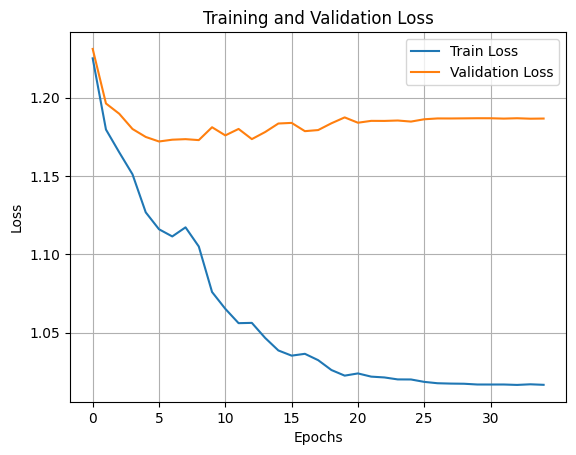

In [191]:
show_learning_curves(history_cnn_50_featured)

In [149]:
y_prob_cnn_50_featured, y_pred_labels_cnn_50_featured = get_prediction(model_trained_cnn_50_featured, test_dataset_featured_50_, featured=True)

print(classification_report(y_test_50_, y_pred_labels_cnn_50_featured))
print(f"ROC-AUC: {roc_auc_score(y_test_50_, y_prob_cnn_50_featured):.4f}")

              precision    recall  f1-score   support

           0       0.95      0.59      0.73      4229
           1       0.14      0.66      0.24       432

    accuracy                           0.60      4661
   macro avg       0.54      0.63      0.48      4661
weighted avg       0.87      0.60      0.68      4661

ROC-AUC: 0.6739


In [150]:
fpr_50_featured_1, tpr_50_featured_1, _ = roc_curve(y_test_50_,  y_prob_cnn_50_featured)

In [151]:
precision_50_featured_1, recall_50_featured_1, thresholds_50_featured_1 = precision_recall_curve(y_test_50_, y_prob_cnn_50_featured)

## 30-bp Nucleotide Context

In [152]:
X_train_full_30_, X_test_30_, y_train_full_30_, y_test_30_, f_train_full_30_, f_test_30_ = train_test_split(
    np.stack(df_featured.seq_30.values), y_featured, features,
    test_size=0.2, random_state=42, stratify=y_featured)

X_train_30_, X_val_30_, y_train_30_, y_val_30_, f_train_30_, f_val_30_ = train_test_split(
    X_train_full_30_, y_train_full_30_, f_train_full_30_,
    test_size=0.3, random_state=42, stratify=y_train_full_30_)

scaler = StandardScaler()

f_train_scaled_30_ = scaler.fit_transform(f_train_30_)
f_val_scaled_30_ = scaler.transform(f_val_30_)
f_test_scaled_30_ = scaler.transform(f_test_30_)


train_dataset_featured_30_ = prepare_tensors_featured(X_train_30_, y_train_30_, f_train_scaled_30_)
val_dataset_featured_30_ = prepare_tensors_featured(X_val_30_, y_val_30_, f_val_scaled_30_)
test_dataset_featured_30_ = prepare_tensors_featured(X_test_30_, y_test_30_, f_test_scaled_30_)


train_loader_featured_30_ = DataLoader(train_dataset_featured_30_, batch_size=128, shuffle=True)
val_loader_featured_30_ = DataLoader(val_dataset_featured_30_, batch_size=128, shuffle=False)

In [ ]:
model_cnn_30_featured = CNN_model_featured(input_len=62, drop_conv=0.4, drop_fc=0.5).to(device)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val)
optimizer = torch.optim.Adam(model_cnn_30_featured.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2)

model_trained_cnn_30_featured, history_cnn_30_featured = train_featured(
    model=model_cnn_30_featured,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_loader=train_loader_featured_30_,
    val_loader=val_loader_featured_30_,
    n_epoch=n_epochs,
    show_step=10,
    scheduler=scheduler,
    use_sample_weights=False,
    save_best=True)

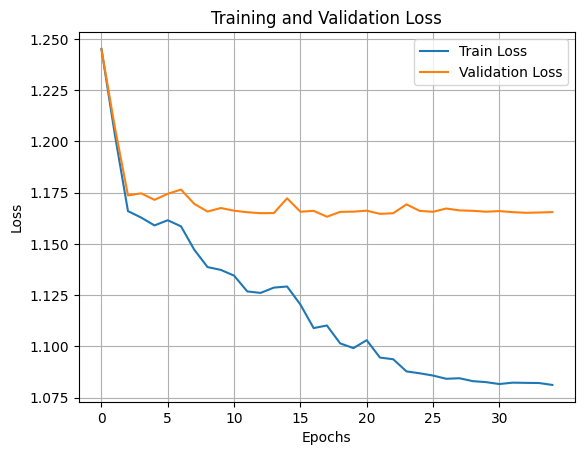

In [192]:
show_learning_curves(history_cnn_30_featured)

In [155]:
y_prob_cnn_30_featured, y_pred_labels_cnn_30_featured = get_prediction(model_trained_cnn_30_featured, test_dataset_featured_30_, featured=True)

print(classification_report(y_test_30_, y_pred_labels_cnn_30_featured))
print(f"ROC-AUC: {roc_auc_score(y_test_30_, y_prob_cnn_30_featured):.4f}")

              precision    recall  f1-score   support

           0       0.95      0.58      0.72      4229
           1       0.14      0.68      0.24       432

    accuracy                           0.59      4661
   macro avg       0.54      0.63      0.48      4661
weighted avg       0.87      0.59      0.68      4661

ROC-AUC: 0.6742


In [156]:
fpr_30_featured_1, tpr_30_featured_1, _ = roc_curve(y_test_30_,  y_prob_cnn_30_featured)

In [157]:
precision_30_featured_1, recall_30_featured_1, thresholds_30_featured_1 = precision_recall_curve(y_test_30_, y_prob_cnn_30_featured)

# Attention-based CNN Classification with Additional Features

In [163]:
class CNN_attention_Featured(nn.Module):
    def __init__(self, input_len=62, extra_features_dim=7, k1=5, k2=3,
                 out1=32, out2=64, drop_conv=0.1, drop_fc=0.4):
        super().__init__()

        self.conv1 = nn.Conv1d(4, out1, kernel_size=k1, padding='same')
        self.bn1 = nn.BatchNorm1d(out1)
        self.pool1 = nn.AvgPool1d(kernel_size=2)
        self.conv2 = nn.Conv1d(out1, out2, kernel_size=k2, padding='same')
        self.bn2 = nn.BatchNorm1d(out2)
        self.attention = AttentionBlock(out2)
        self.dropout_conv = nn.Dropout1d(drop_conv)
        self.flatten = nn.Flatten()
        cnn_out_dim = out2 * (input_len // 2)
        self.fc1 = nn.Linear(cnn_out_dim + extra_features_dim, 128)
        self.dropout_fc = nn.Dropout(drop_fc)
        self.fc2 = nn.Linear(128, 1)

    def _forward_single_strand(self, x_seq, x_extra):
        x = F.relu(self.bn1(self.conv1(x_seq)))
        x = self.pool1(x)
        x = self.dropout_conv(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.dropout_conv(x)
        x = x.permute(0, 2, 1)
        identity = x
        x = self.attention(x)
        x = x + identity
        x = self.flatten(x)
        combined = torch.cat((x, x_extra), dim=1)
        x = F.relu(self.fc1(combined))
        x = self.dropout_fc(x)
        x = self.fc2(x)
        return x

    def forward(self, x_seq, x_extra, use_rc=True):
        if x_seq.dim() == 2:
             x_seq = x_seq.view(-1, 4, self.input_len)
        elif x_seq.shape[1] != 4:
             x_seq = x_seq.transpose(1, 2)
        out_forward = self._forward_single_strand(x_seq, x_extra)
        if use_rc:
            x_rc = get_reverse_complement(x_seq)
            out_rc = self._forward_single_strand(x_rc, x_extra)
            return (out_forward + out_rc) / 2.0
        else:
            return out_forward

## 50-bp Nucleotide Context

In [ ]:
CNNA_model_featured_50 = CNN_attention_Featured(input_len=102,
                                                extra_features_dim=7,
                                                k1=7,
                                                k2=5,
                                                out1=16,
                                                out2=64, drop_conv=0.4, drop_fc=0.5).to(device)


loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val)
optimizer = torch.optim.Adam(CNNA_model_featured_50.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2)

model_trained_ccna_50_featured, history_cnna_50_featured = train_featured(
    model=CNNA_model_featured_50,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_loader=train_loader_featured_50_,
    val_loader=val_loader_featured_50_,
    n_epoch=n_epochs,
    show_step=10,
    scheduler=scheduler,
    use_sample_weights=False,
    save_best=True)

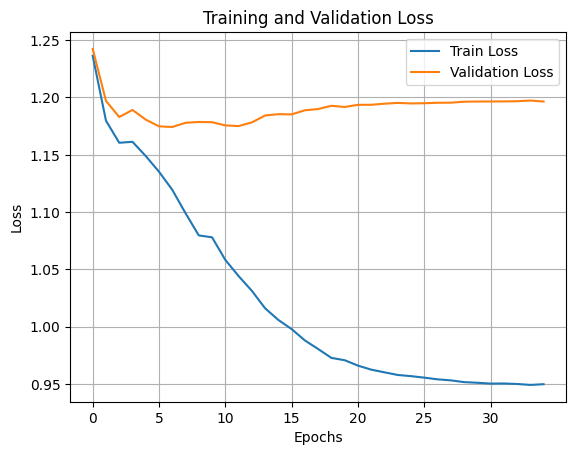

In [193]:
show_learning_curves(history_cnna_50_featured)

In [166]:
y_prob_cnna_50_featured, y_pred_labels_cnna_50_featured = get_prediction(model_trained_ccna_50_featured, test_dataset_featured_50_, featured=True)

print(classification_report(y_test_50_, y_pred_labels_cnna_50_featured))
print(f"ROC-AUC: {roc_auc_score(y_test_50_, y_prob_cnna_50_featured):.4f}")

              precision    recall  f1-score   support

           0       0.94      0.63      0.76      4229
           1       0.15      0.63      0.24       432

    accuracy                           0.63      4661
   macro avg       0.55      0.63      0.50      4661
weighted avg       0.87      0.63      0.71      4661

ROC-AUC: 0.6733


In [167]:
fpr_50_featured_2, tpr_50_featured_2, _ = roc_curve(y_test_50_,  y_prob_cnna_50_featured)

In [168]:
precision_50_featured_2, recall_50_featured_2, thresholds_50_featured_2 = precision_recall_curve(y_test_50_, y_prob_cnna_50_featured)

## 30-bp Nucleotide Context

In [ ]:
CNNA_model_featured_30 = CNN_attention_Featured(input_len=62,
                                                extra_features_dim=7,
                                                k1=5,
                                                k2=3,
                                                out1=16,
                                                out2=64, drop_conv=0.4, drop_fc=0.6).to(device)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val)
optimizer = torch.optim.Adam(CNNA_model_featured_30.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2)

model_trained_cnna_30_featured, history_cnna_30_featured = train_featured(
    model=CNNA_model_featured_30,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_loader=train_loader_featured_30_,
    val_loader=val_loader_featured_30_,
    n_epoch=n_epochs,
    show_step=10,
    scheduler=scheduler,
    use_sample_weights=False,
    save_best=True)

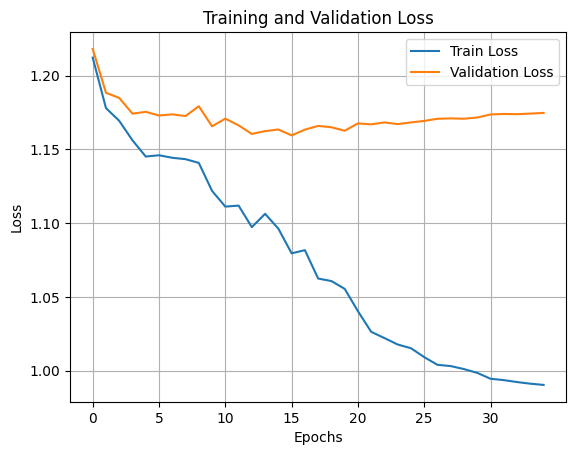

In [194]:
show_learning_curves(history_cnna_30_featured)

In [171]:
y_prob_cnna_30_featured, y_pred_labels_cnna_30_featured = get_prediction(model_trained_cnna_30_featured, test_dataset_featured_30_, featured=True)

print(classification_report(y_test_30_, y_pred_labels_cnna_30_featured))
print(f"ROC-AUC: {roc_auc_score(y_test_30_, y_prob_cnna_30_featured):.4f}")

              precision    recall  f1-score   support

           0       0.94      0.58      0.72      4229
           1       0.14      0.66      0.23       432

    accuracy                           0.59      4661
   macro avg       0.54      0.62      0.48      4661
weighted avg       0.87      0.59      0.67      4661

ROC-AUC: 0.6726


In [172]:
fpr_30_featured_2, tpr_30_featured_2, _ = roc_curve(y_test_30_,  y_prob_cnna_30_featured)

In [173]:
precision_30_featured_2, recall_30_featured_2, thresholds_30_featured_2 = precision_recall_curve(y_test_30_, y_prob_cnna_30_featured)

# Evaluation of Predictive Performance

## CNN Results

### 50-bp Nucleotide Context

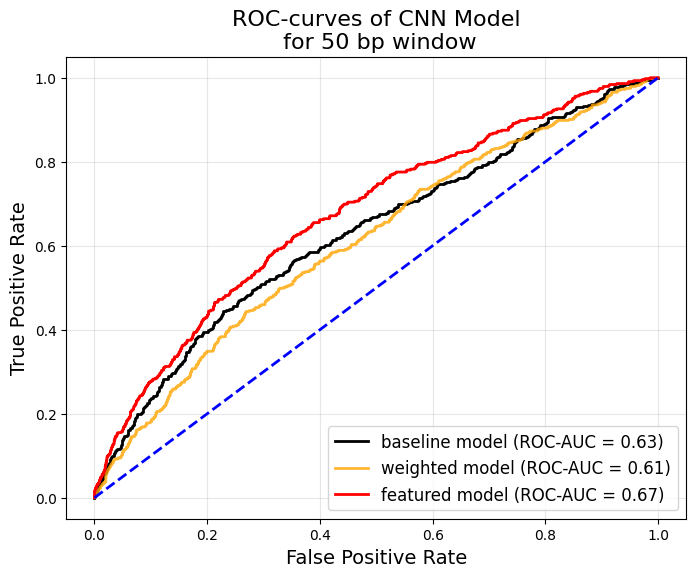

In [174]:
show_roc_curves([fpr_50_1, fpr_50_w_1, fpr_50_featured_1],
                [tpr_50_1, tpr_50_w_1, tpr_50_featured_1],
                50,
                'CNN')

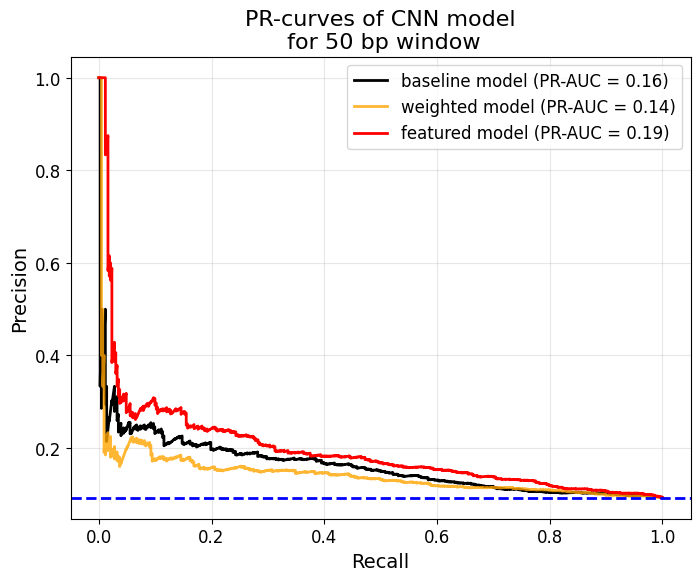

In [175]:
show_pr_curves([precision_50_1, precision_50_w_1, precision_50_featured_1],
                [recall_50_1, recall_50_w_1, recall_50_featured_1],
                Counter(y)[1] / (Counter(y)[0] + Counter(y)[1]),
                50,
                'CNN')


### 30-bp Nucleotide Context

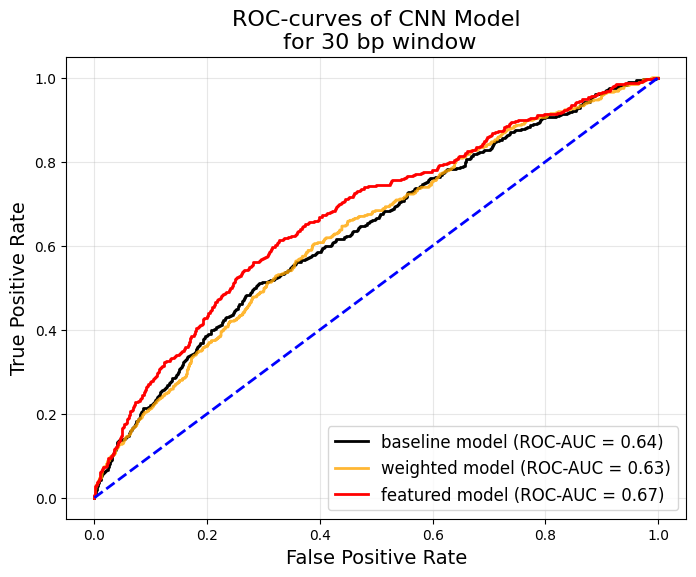

In [176]:
show_roc_curves([fpr_30_1, fpr_30_w_1, fpr_30_featured_1],
                [tpr_30_1, tpr_30_w_1, tpr_30_featured_1],
                30,
                'CNN')

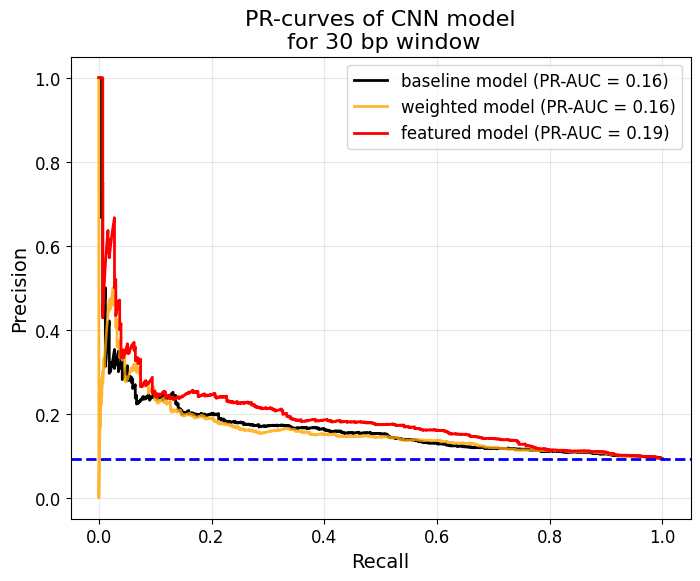

In [177]:
show_pr_curves([precision_30_1, precision_30_w_1, precision_30_featured_1],
                [recall_30_1, recall_30_w_1, recall_30_featured_1],
                Counter(y)[1] / (Counter(y)[0] + Counter(y)[1]),
                30,
                'CNN')

## Attention-based CNN Results

### 50-bp Nucleotide Context

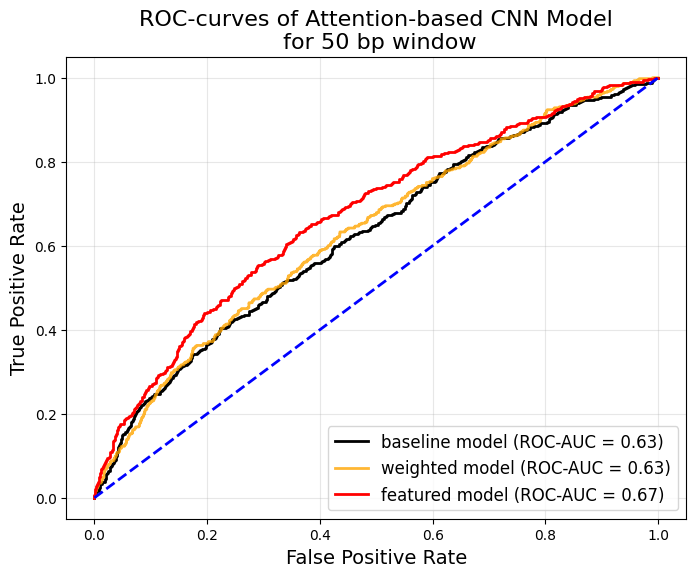

In [178]:
show_roc_curves([fpr_50_2, fpr_50_w_2, fpr_50_featured_2],
                [tpr_50_2, tpr_50_w_2, tpr_50_featured_2],
                50,
                'Attention-based CNN')

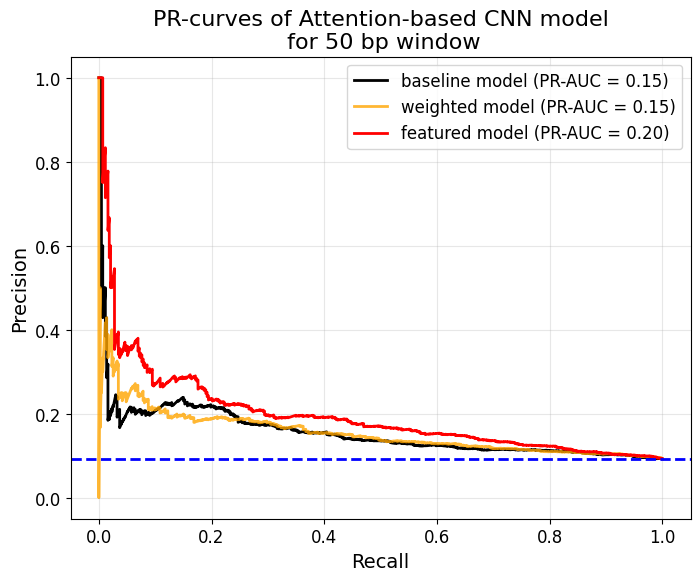

In [179]:
show_pr_curves([precision_50_2, precision_50_w_2, precision_50_featured_2],
                [recall_50_2, recall_50_w_2, recall_50_featured_2],
                Counter(y)[1] / (Counter(y)[0] + Counter(y)[1]),
                50,
                'Attention-based CNN')

### 30-bp Nucleotide Context

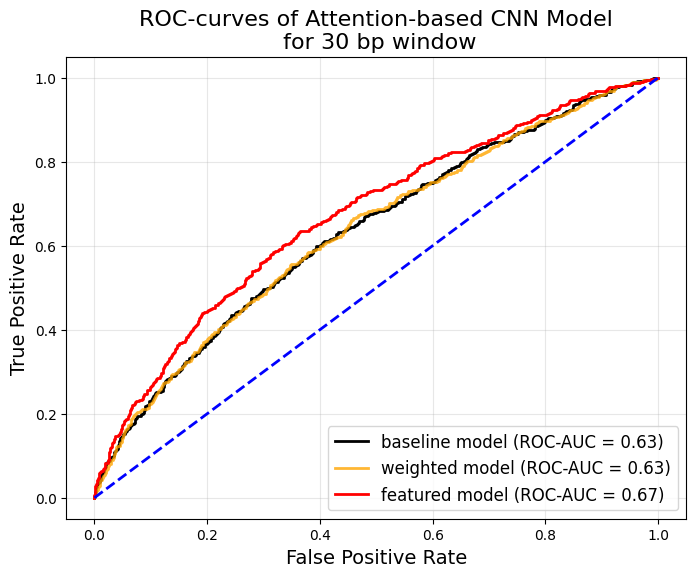

In [180]:
show_roc_curves([fpr_30_2, fpr_30_w_2, fpr_30_featured_2],
                [tpr_30_2, tpr_30_w_2, tpr_30_featured_2],
                30,
                'Attention-based CNN')

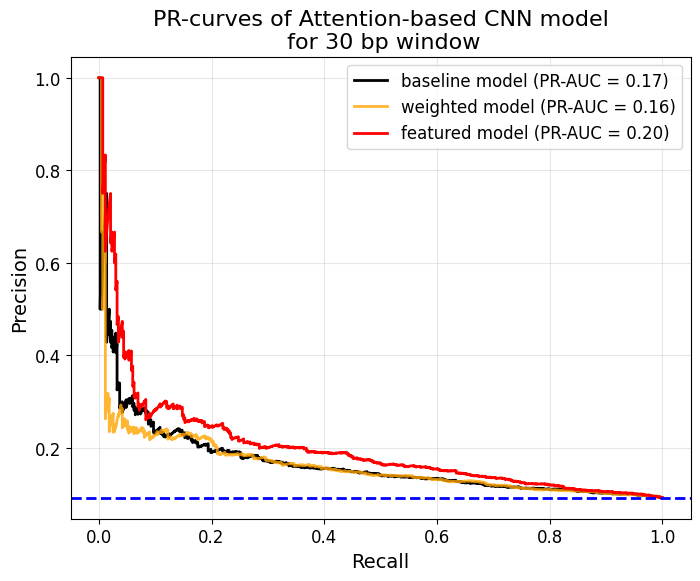

In [181]:
show_pr_curves([precision_30_2, precision_30_w_2, precision_30_featured_2],
                [recall_30_2, recall_30_w_2, recall_30_featured_2],
                Counter(y)[1] / (Counter(y)[0] + Counter(y)[1]),
                30,
                'Attention-based CNN')